In [ ]:
import numpy as np
import pandas as pd
import matplotlib. pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer,  
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import WordCloud
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [ ]:
df = pd.read_csv('movies.csv').drop(columns=['index', 'homepage', 'id'])
required_columns = ['genres', 'keywords', 'overview', 'title']
df = df[required_columns]
df.head()

,genres,keywords,overview,title
0,Action Adventure Fantasy Science Fiction,culture clash future space war space colony so...,"In the 22nd century, a paraplegic Marine is di...",Avatar
1,Adventure Fantasy Action,ocean drug abuse exotic island east india trad...,"Captain Barbossa, long believed to be dead, ha...",Pirates of the Caribbean: At World's End
2,Action Adventure Crime,spy based on novel secret agent sequel mi6,A cryptic message from Bond’s past sends him o...,Spectre
3,Action Crime Drama Thriller,dc comics crime fighter terrorist secret ident...,Following the death of District Attorney Harve...,The Dark Knight Rises
4,Action Adventure Science Fiction,based on novel mars medallion space travel pri...,"John Carter is a war-weary, former military ca...",John Carter


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   genres    4775 non-null   object
 1   keywords  4391 non-null   object
 2   overview  4800 non-null   object
 3   title     4803 non-null   object
dtypes: object(4)
memory usage: 150.2+ KB


In [4]:
round((df.isna().sum().sort_values(ascending=False)/len(df))*100, 2)

keywords    8.58
genres      0.58
overview    0.06
title       0.00
dtype: float64

In [ ]:
df = df.dropna()

In [6]:
df.head()

,genres,keywords,overview,title
0,Action Adventure Fantasy Science Fiction,culture clash future space war space colony so...,"In the 22nd century, a paraplegic Marine is di...",Avatar
1,Adventure Fantasy Action,ocean drug abuse exotic island east india trad...,"Captain Barbossa, long believed to be dead, ha...",Pirates of the Caribbean: At World's End
2,Action Adventure Crime,spy based on novel secret agent sequel mi6,A cryptic message from Bond’s past sends him o...,Spectre
3,Action Crime Drama Thriller,dc comics crime fighter terrorist secret ident...,Following the death of District Attorney Harve...,The Dark Knight Rises
4,Action Adventure Science Fiction,based on novel mars medallion space travel pri...,"John Carter is a war-weary, former military ca...",John Carter


In [7]:
df['combined'] = df['genres'] + ' : ' + df['keywords'] + ' : ' + df['overview']

In [8]:
data = df[['title', 'combined']]
data

,title,combined
0,Avatar,Action Adventure Fantasy Science Fiction : cul...
1,Pirates of the Caribbean: At World's End,Adventure Fantasy Action : ocean drug abuse ex...
2,Spectre,Action Adventure Crime : spy based on novel se...
3,The Dark Knight Rises,Action Crime Drama Thriller : dc comics crime ...
4,John Carter,Action Adventure Science Fiction : based on no...
...,...,...
4795,Bang,Drama : gang audition police fake homeless act...
4796,Primer,Science Fiction Drama Thriller : distrust gara...
4798,El Mariachi,Action Crime Thriller : united states\u2013mex...
4800,"Signed, Sealed, Delivered",Comedy Drama Romance TV Movie : date love at f...


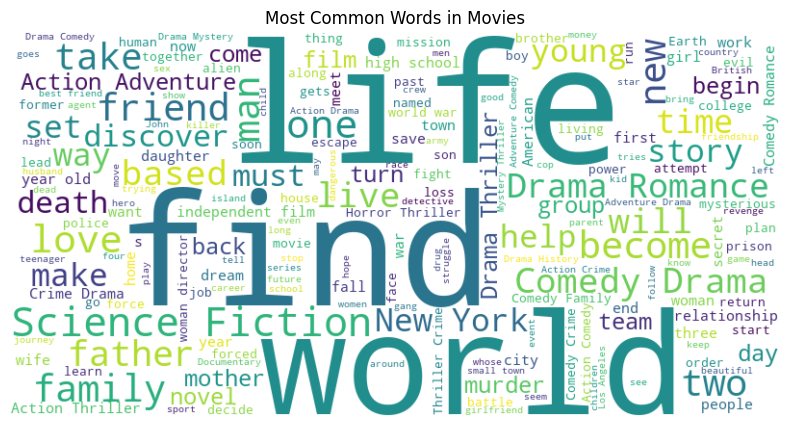

In [ ]:
combined_text = " ".join(df['combined'])
wordcloud = WordCloud(width=800, height=400,
                      background_color='white').generate(combined_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Movies')
plt.show()

In [ ]:
# Download the stopwords from nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\piyus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\piyus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\piyus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [11]:
stop_words = set(stopwords.words('english'))

In [ ]:
def preprocess_text(text):
    # Remove special characters and digits, them convert to lowercase
    text = re.sub(r"[^a-zA-Z\s]", "", text).lower()
    # Tokenize the text
    tokens = word_tokenize(text)
    # Remove stopwords
    token = [word for word in tokens if word not in stop_words]
    return " ".join(token)

In [ ]:
data.iloc[:, -1:] = data['combined'].apply(preprocess_text)
data.head()

,title,combined
0,Avatar,action adventure fantasy science fiction cultu...
1,Pirates of the Caribbean: At World's End,adventure fantasy action ocean drug abuse exot...
2,Spectre,action adventure crime spy based novel secret ...
3,The Dark Knight Rises,action crime drama thriller dc comics crime fi...
4,John Carter,action adventure science fiction based novel m...


In [14]:
data.head()

,title,combined
0,Avatar,action adventure fantasy science fiction cultu...
1,Pirates of the Caribbean: At World's End,adventure fantasy action ocean drug abuse exot...
2,Spectre,action adventure crime spy based novel secret ...
3,The Dark Knight Rises,action crime drama thriller dc comics crime fi...
4,John Carter,action adventure science fiction based novel m...


In [ ]:
tf_idf = TfidfVectorizer(max_features=5000, stop_words='english')
tf_idf_matrix = tf_idf.fit_transform(data['combined'])

In [18]:
tf_idf_matrix.shape

(4387, 22453)

In [ ]:
# calculate the cosine similarity matrix

cosine_sim = cosine_similarity(X=tf_idf_matrix)
cosine_sim.shape

(4387, 4387)

In [ ]:
# recommendation function
def recommend_movies(query, cosine_sim=cosine_sim, df=data, top_n=5):
    # Get the index of the movie from the query
    idx = df[df['title'].str.lower() == query.lower()].index
    if len(idx) == 0:
        return "Movie not found in the database."
    idx = idx[0]
    # get the pairwise similarity scores of all movies with that movie
    sim_scores = list(enumerate(cosine_sim[idx]))
    # sort the movies based on the similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    # get the scores of the top n most similar movies
    sim_scores = sim_scores[1:top_n+1]

    movie_indices = [i[0] for i in sim_scores]

    return df[['title']].iloc[movie_indices]

In [ ]:
print(recommend_movies("The Dark Knight", top_n=10 ))

                                        title
3                       The Dark Knight Rises
428                            Batman Returns
3854  Batman: The Dark Knight Returns, Part 2
119                             Batman Begins
1359                                   Batman
299                            Batman Forever
210                            Batman & Robin
205        Sherlock Holmes: A Game of Shadows
9          Batman v Superman: Dawn of Justice
879                       Law Abiding Citizen


In [55]:
import pandas as pd

df = pd.DataFrame({'Name': ['Aman', 'Raj'], 'Age': [25, 32]})
df

,Name,Age
0,Aman,25
1,Raj,32


In [56]:

# Iterating through the DataFrame
for index, row in df.iterrows():
    print(f"Index: {index}, Name: {row['Name']}, Age: {row['Age']}")

Index: 0, Name: Aman, Age: 25
Index: 1, Name: Raj, Age: 32


<generator object DataFrame.iterrows at 0x000002A3806C94A0>